In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as lr 
import matplotlib.pyplot as plt

## Data:

In [4]:
path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv"
df = pd.read_csv(path)

# Vi standardisere vores features.
variables = df.columns[1:27].tolist()
scaler = StandardScaler()
df[variables] = scaler.fit_transform(df[variables])

# Test Data:
path_testdata = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv"
test_data = pd.read_csv(path_testdata)
test_data[variables] = scaler.transform(test_data[variables])


## Functions:

In [11]:
def multiple_regression_foreach(df,complication, variables):
    '''
    Input: df (dataframe), variables (all the variables you want to include in the regression as a list)
    Returns: (intercept, [list of coefficients])
    '''
    n = len(df)
    d = len(variables)

    # construct empty design matrix
    X = np.zeros((n, d))

    # targets
    y = df[complication]

    # fill out design matrix 
    for i in range(d):
        X[:, i] = df[variables[i]]
    
    #make model
    model = lr()
    #fit model
    model.fit(X,  y)
    return model.intercept_, model.coef_

def FL_mul_reg_foreach(df, variables,complication, num_clients, weighted = True):
    d = len(variables)
    k = num_clients
    n = len(df)
    all_coefs = np.zeros((k, d+2))
    for i in range(1, num_clients+1):
        client_data = df[df["Client"] == i]
        if len(client_data) > 0:
            inter, coefs = multiple_regression_foreach(client_data,complication, variables)
            all_coefs[i-1, 0] = inter
            all_coefs[i-1, 1] = len(client_data)
            all_coefs[i-1, 2:] = coefs

    # vægtet gennemsnit
    if weighted:
        means_intercept = 0
        means_coefs = np.zeros(d)
        for i in range(k):
            means_intercept += all_coefs[i, 1] * all_coefs[i, 0]
        means_intercept /= n
        for i in range(d):
            for j in range(k):
                means_coefs[i] += all_coefs[j, 1] * all_coefs[j, i+2]
            means_coefs[i] /= n

    # det simple ikke-vægtede gennemsnit
    if not weighted:
        means_intercept = np.mean(all_coefs[:, 0])
        means_coefs = np.mean(all_coefs[:, 2:], axis=0)

    return means_intercept, means_coefs


def foreach(df, variables, num_clients, complications):
    result = {}
    for complication in complications:
        intercept, coefs = FL_mul_reg_foreach(df, variables,complication, num_clients, weighted = True)
        result[complication] = (intercept, coefs)
    return result


def predict_from_coefs(df, variables, intercept, coefs):
    """
    Beregner y-hat = intercept + X beta
    for alle rækker i df.
    """
    X = df[variables].to_numpy()
    y_hat = intercept + X @ coefs
    return y_hat

def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

def predict_and_group_all(test_df, variables, model_results):
    """
    model_results er fx output fra:
        results = foreach(df, variables, num_clients, complications)

    Returnerer et dataframe med predictions og gruppeinddeling
    for hver complication.
    """
    out = test_df.copy()
    cutoffs = {}

    for complication, (intercept, coefs) in model_results.items():
        y_hat = predict_from_coefs(test_df, variables, intercept, coefs)
        groups, q1, q2 = assign_tertiles(y_hat)

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs


def metrics_for_one_complication(df, complication):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    true_col = complication.replace("Risk_", "Risk_Category_", 1)
    pred_col = f"{complication}_group"
    
    y_true = df[true_col].to_numpy()
    y_pred = df[pred_col].to_numpy()
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "true_col": true_col,
        "pred_col": pred_col,
        "per_class": results,
        "macro_f1": macro_f1
    }

def metrics_for_all_complications(df, complications):
    all_results = {}
    macro_f1s = []

    for complication in complications:
        res = metrics_for_one_complication(df, complication)
        all_results[complication] = res
        macro_f1s.append(res["macro_f1"])

    # svarer til f1_global_macro i din pipeline
    overall_macro_f1 = np.mean(macro_f1s)

    return all_results, overall_macro_f1


# function that plots the absolute values of the coefficients
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

def plot_all_complications(results, variables):
    for complication, (intercept, coefs) in results.items():
        plot_magnitude(
            coefs,
            variables,
            title=f"Coefficient magnitudes - {complication}"
            )


## Results:

In [8]:
complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

results = foreach(df, variables, 10, complications)

test_with_preds, cutoffs = predict_and_group_all(test_data, variables, results)

results, overall_f1 = metrics_for_all_complications(test_with_preds, complications)

for complication, res in results.items():
    print(f"\n--- {complication} ---")
    print(f"True column: {res['true_col']}")
    print(f"Pred column: {res['pred_col']}")
    
    for cls in [0, 1, 2]:
        vals = res["per_class"][cls]
        print(
            f"Class {cls}: "
            f"Precision={vals['precision']:.3f}, "
            f"Recall={vals['recall']:.3f}, "
            f"F1={vals['f1']:.3f}"
        )
    
    print(f"Macro F1 = {res['macro_f1']:.3f}")

print("\n==============================")
print(f"FINAL F1 (mean over risks) = {overall_f1:.3f}")
print("==============================")


--- Risk_AlveolarOsteitis ---
True column: Risk_Category_AlveolarOsteitis
Pred column: Risk_AlveolarOsteitis_group
Class 0: Precision=0.765, Recall=0.793, F1=0.779
Class 1: Precision=0.522, Recall=0.508, F1=0.515
Class 2: Precision=0.698, Recall=0.692, F1=0.695
Macro F1 = 0.663

--- Risk_SecondaryInfection ---
True column: Risk_Category_SecondaryInfection
Pred column: Risk_SecondaryInfection_group
Class 0: Precision=0.686, Recall=0.715, F1=0.700
Class 1: Precision=0.538, Recall=0.518, F1=0.528
Class 2: Precision=0.733, Recall=0.732, F1=0.732
Macro F1 = 0.653

--- Risk_NerveDysesthesia ---
True column: Risk_Category_NerveDysesthesia
Pred column: Risk_NerveDysesthesia_group
Class 0: Precision=0.742, Recall=0.810, F1=0.775
Class 1: Precision=0.621, Recall=0.566, F1=0.592
Class 2: Precision=0.763, Recall=0.774, F1=0.768
Macro F1 = 0.712

--- Risk_Bleeding ---
True column: Risk_Category_Bleeding
Pred column: Risk_Bleeding_group
Class 0: Precision=0.501, Recall=0.584, F1=0.539
Class 1: Prec

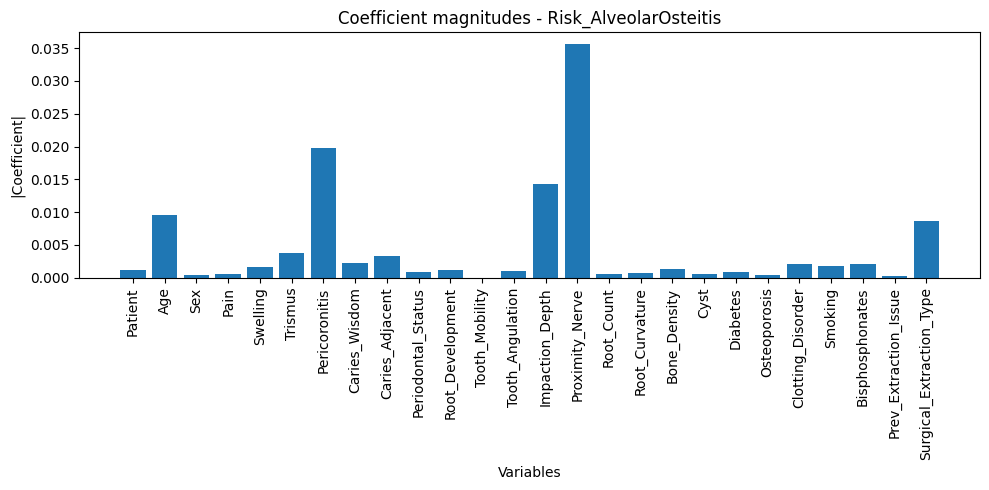

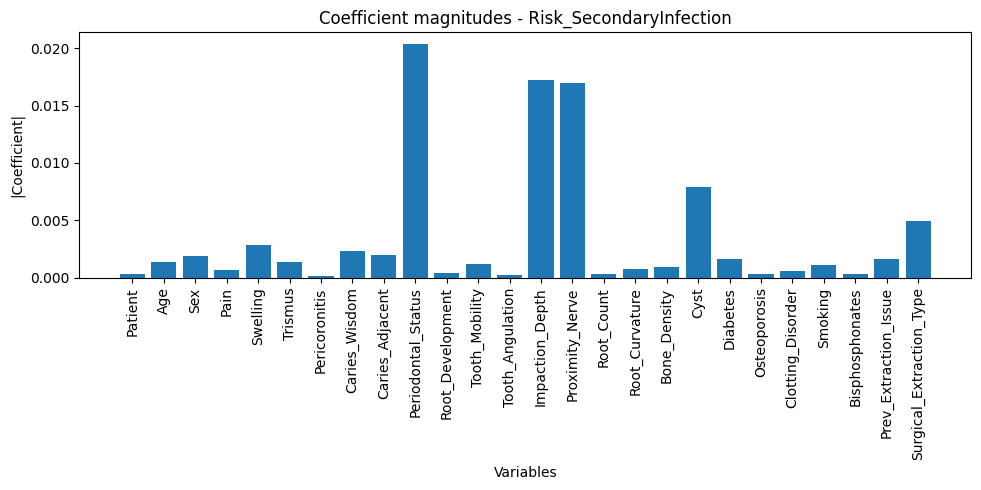

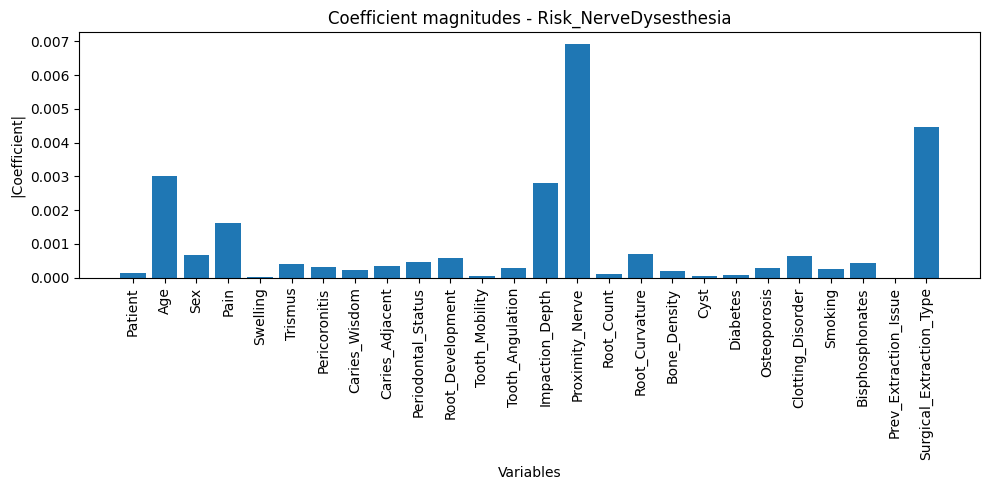

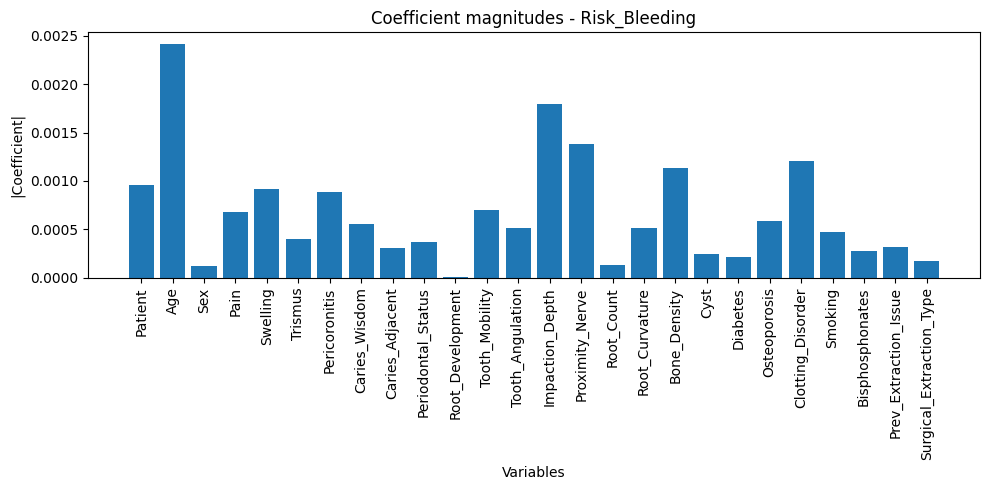

In [12]:
results_fed = foreach(df, variables, 10, complications)
plot_all_complications(results_fed, variables)